In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

conn = sqlite3.connect("../data/db/bluestock_mf.db")

In [3]:
nav_history = pd.read_sql("SELECT * FROM nav_history", conn)
aum_house = pd.read_sql("SELECT * FROM aum_by_fund_house", conn)
monthly_sip = pd.read_sql("SELECT * FROM monthly_sip_inflows", conn)
category_inflows = pd.read_sql("SELECT * FROM category_inflows", conn)
investor_transactions = pd.read_sql("SELECT * FROM investor_transactions", conn)
industry_folio = pd.read_sql("SELECT * FROM industry_folio_count", conn)
portfolio_holdings = pd.read_sql("SELECT * FROM portfolio_holdings", conn)
scheme_performance = pd.read_sql("SELECT * FROM scheme_performance", conn)

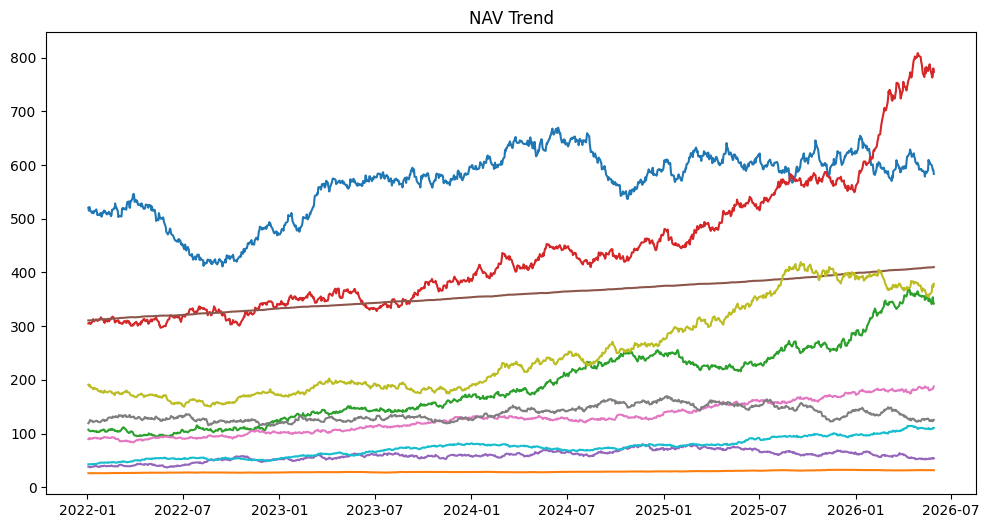

In [4]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

plt.figure(figsize=(12,6))

for fund in nav_history["amfi_code"].unique()[:10]:
    temp = nav_history[nav_history["amfi_code"] == fund]
    plt.plot(temp["date"], temp["nav"])

plt.title("NAV Trend")
plt.show()

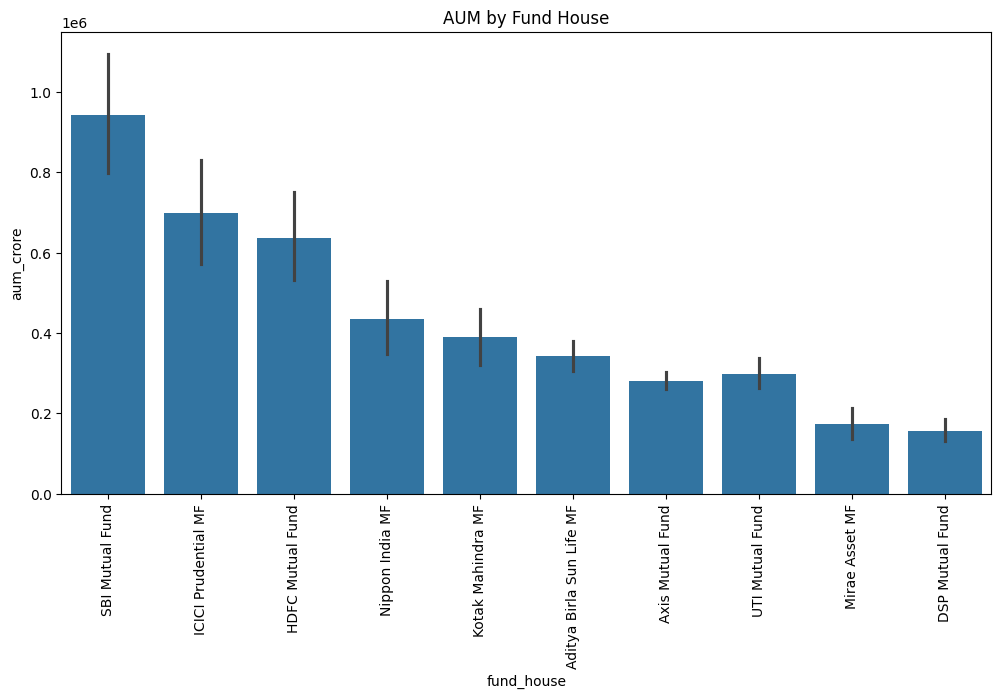

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_house,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)
plt.title("AUM by Fund House")
plt.show()

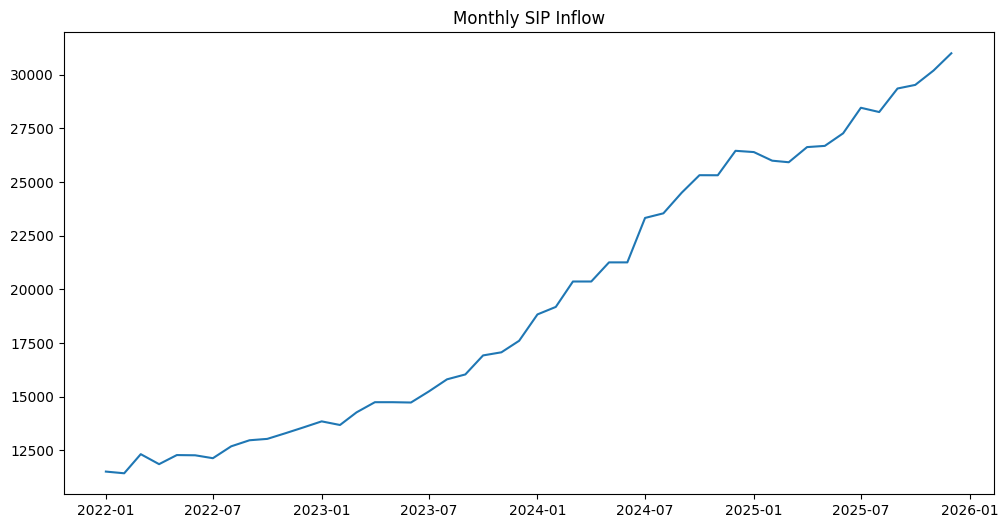

In [6]:
monthly_sip["month"] = pd.to_datetime(monthly_sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sip["month"],
    monthly_sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow")
plt.show()

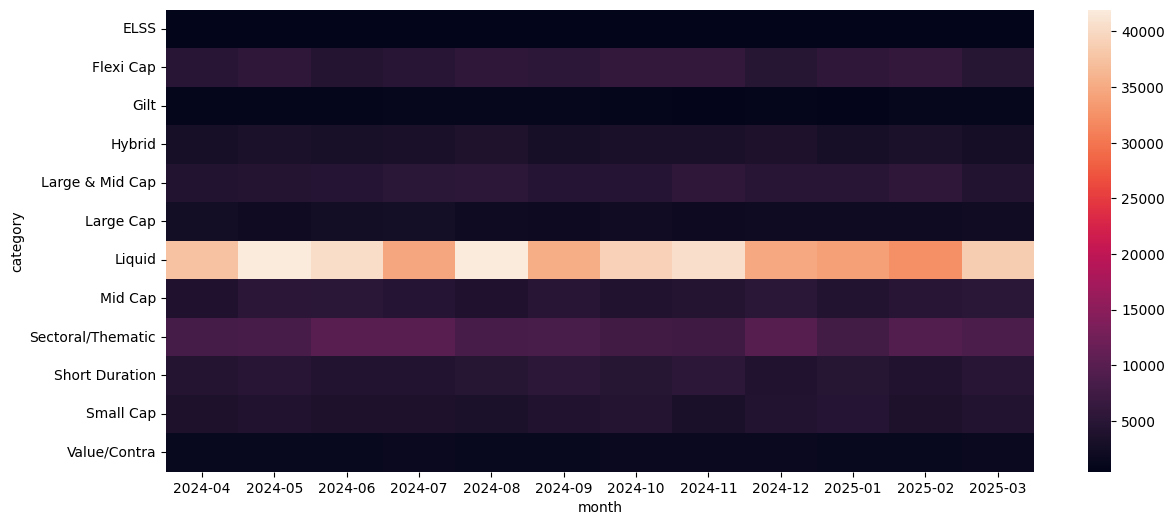

In [7]:
pivot = category_inflows.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot)
plt.show()

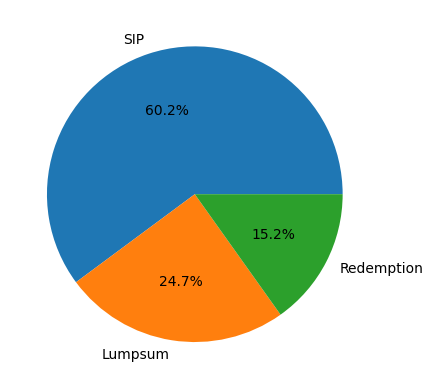

In [8]:
investor_transactions["transaction_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

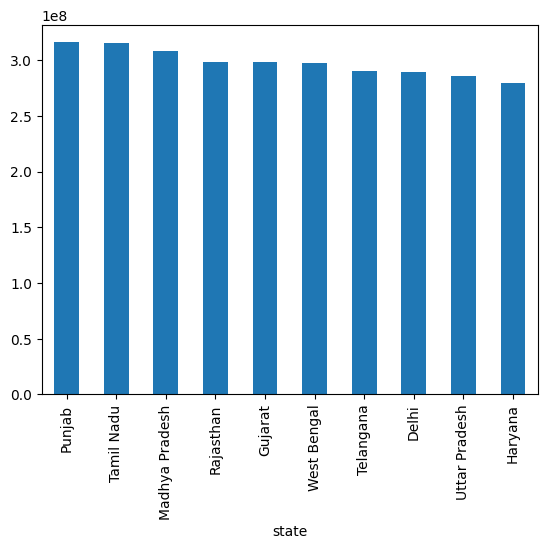

In [9]:
investor_transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.show()

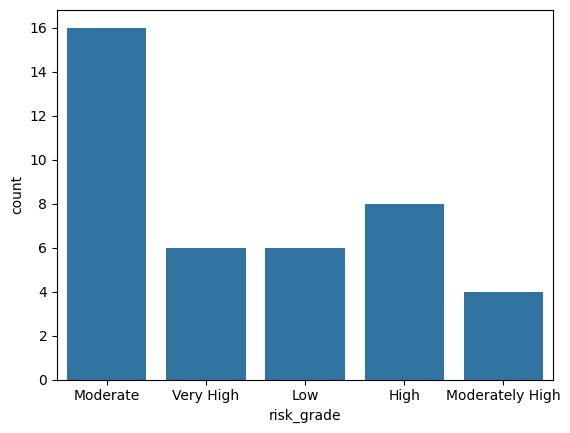

In [10]:
sns.countplot(
    data=scheme_performance,
    x="risk_grade"
)

plt.show()

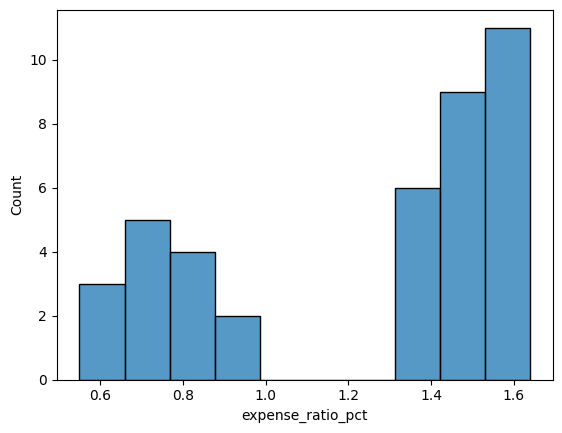

In [11]:
sns.histplot(
    scheme_performance["expense_ratio_pct"],
    bins=10
)

plt.show()

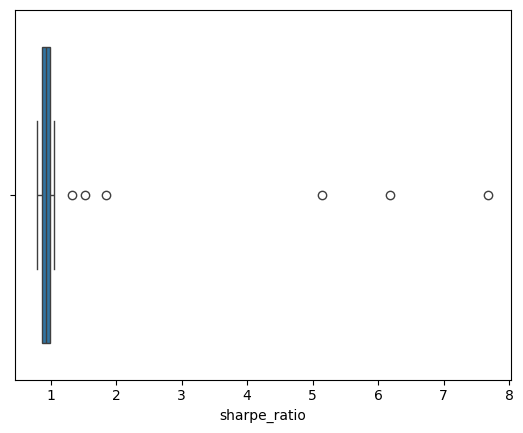

In [12]:
sns.boxplot(
    x=scheme_performance["sharpe_ratio"]
)

plt.show()

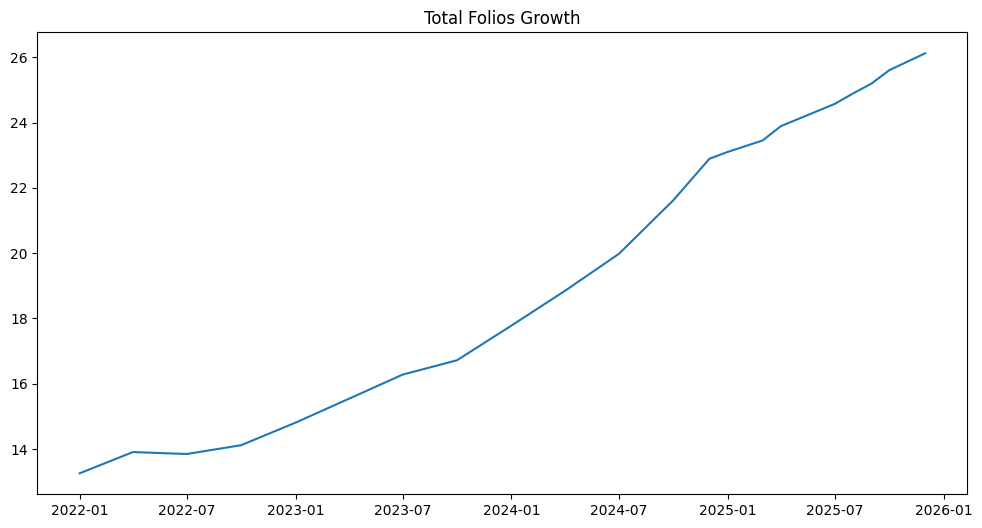

In [13]:
industry_folio["month"] = pd.to_datetime(
    industry_folio["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    industry_folio["month"],
    industry_folio["total_folios_crore"]
)

plt.title("Total Folios Growth")
plt.show()

### Insight

SIP inflows show a consistent upward trend from 2022–2025, indicating increasing retail participation in mutual funds.

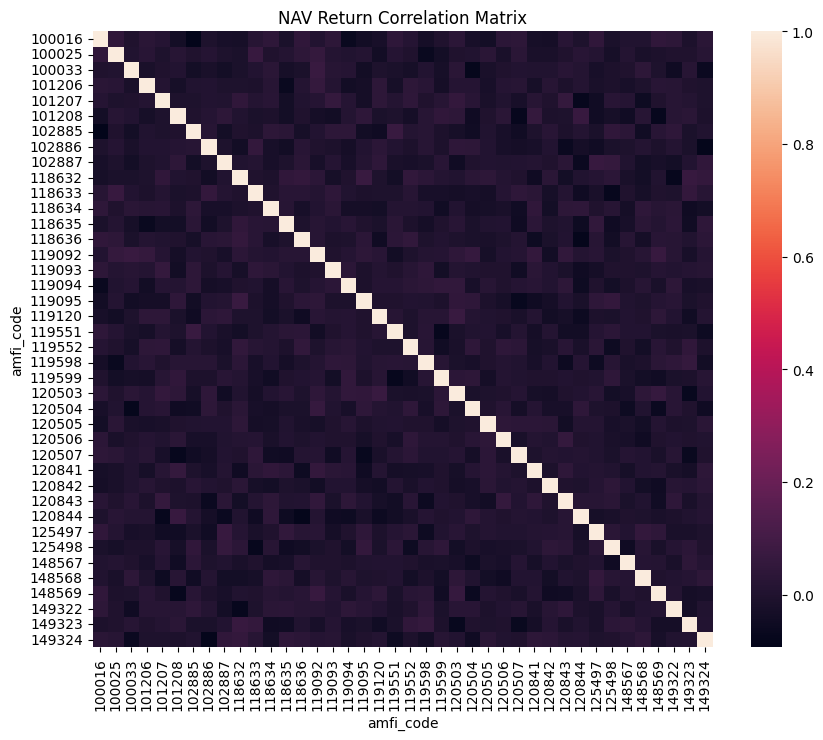

In [14]:
nav_pivot = nav_history.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = nav_pivot.pct_change()

plt.figure(figsize=(10,8))
sns.heatmap(returns.corr())
plt.title("NAV Return Correlation Matrix")
plt.show()

In [15]:
portfolio_holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

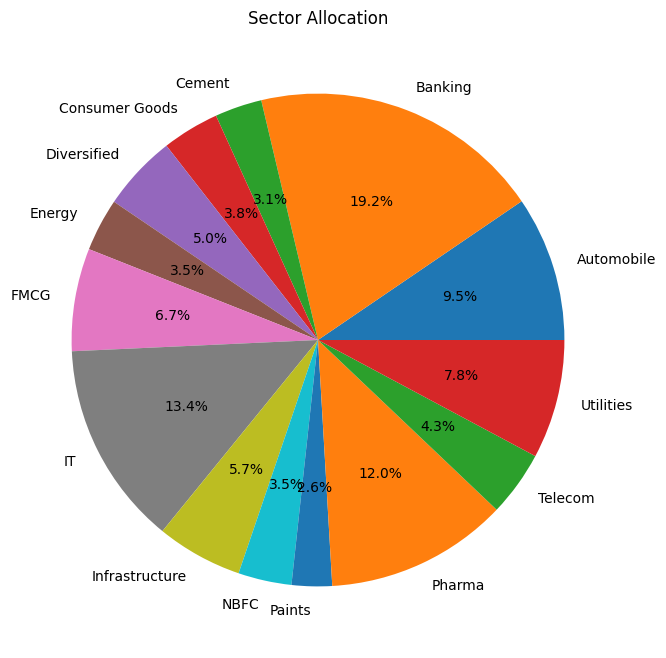

In [16]:
sector_data = portfolio_holdings.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")
plt.show()

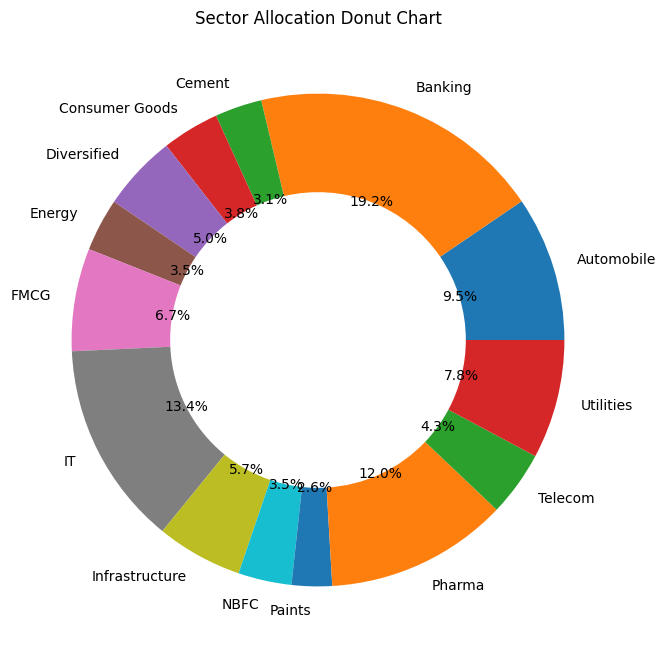

In [17]:
sector_data = portfolio_holdings.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Donut Chart")
plt.show()

### Insight

Financials and Technology sectors constitute the largest portion of portfolio allocations, indicating a concentration in major market sectors.

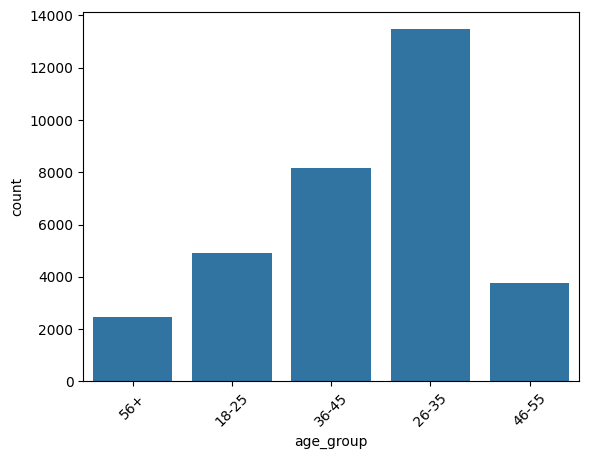

In [18]:
sns.countplot(data=investor_transactions, x="age_group")
plt.xticks(rotation=45)
plt.show()

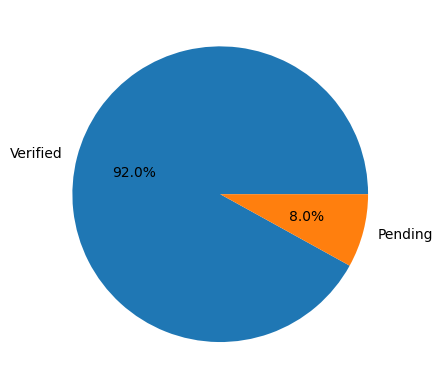

In [19]:
investor_transactions["kyc_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.show()

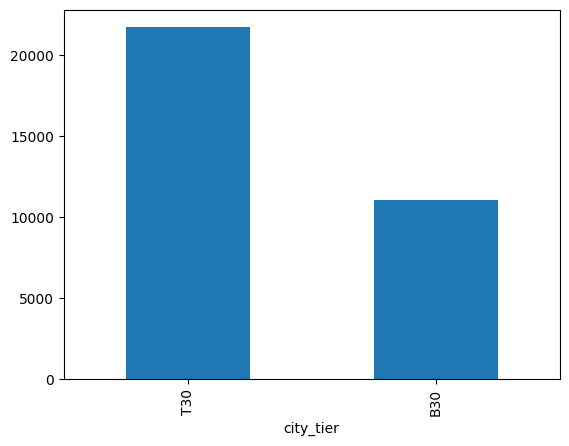

In [20]:
investor_transactions["city_tier"].value_counts().plot(
    kind="bar"
)
plt.show()

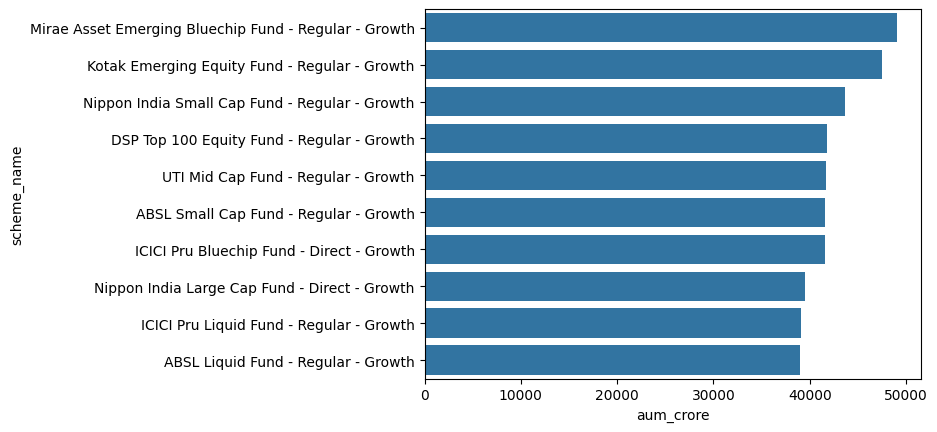

In [21]:
top10 = scheme_performance.sort_values(
    "aum_crore",
    ascending=False
).head(10)

sns.barplot(data=top10, x="aum_crore", y="scheme_name")
plt.show()